# Homework 1: Earthquakes and Plate Tectonics

### Import necessary libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
from matplotlib import cm
import cartopy.crs as ccrs
from cartopy.io.shapereader import Reader
from numpy.ma.core import shape

## Exercise 1 - Global maps to understand Plate Tectonics

**1a - Topography**

Let us use the `Orthographic` projection (A GLOBE! in the XKCD map projection cartoon) to look at the large underwater mountain range of the Mid-Atlantic ridge.

The `plt.contourf` function is slow such that we will need to have some patience when running the plotting code.

First load the .txt files using NumPy (code provided), then create a mesh grid for latitude and longitude (np.meshgrid())

(5 points)

In [6]:
help(np.meshgrid)

Help on _ArrayFunctionDispatcher in module numpy:

meshgrid(*xi, copy=True, sparse=False, indexing='xy')
    Return a tuple of coordinate matrices from coordinate vectors.

    Make N-D coordinate arrays for vectorized evaluations of
    N-D scalar/vector fields over N-D grids, given
    one-dimensional coordinate arrays x1, x2,..., xn.

    Parameters
    ----------
    x1, x2,..., xn : array_like
        1-D arrays representing the coordinates of a grid.
    indexing : {'xy', 'ij'}, optional
        Cartesian ('xy', default) or matrix ('ij') indexing of output.
        See Notes for more details.
    sparse : bool, optional
        If True the shape of the returned coordinate array for dimension *i*
        is reduced from ``(N1, ..., Ni, ... Nn)`` to
        ``(1, ..., 1, Ni, 1, ..., 1)``.  These sparse coordinate grids are
        intended to be used with :ref:`basics.broadcasting`.  When all
        coordinates are used in an expression, broadcasting still leads to a
        fully

In [22]:
## Load the topography data using np.loadtxt
lats = np.loadtxt("data/etopo20lats.txt")
lons = np.loadtxt("data/etopo20lons.txt")
topo_grid = np.loadtxt("data/etopo20data.txt")

## Create a meshgrid for latitude and longitude using np.meshgrid
lon_grid, lat_grid = np.meshgrid(lons, lats)

## Check the shape of lat_grid, lon_grid, and topo_grid are the same
print(f"Shape of lat_grid: {lat_grid.shape}, Shape of lon_grid: {lon_grid.shape}, Shape of topo_grid: {topo_grid.shape}")

## Downsample the data to make the plotting faster
lon_grid = lon_grid[::2, ::2]
lat_grid = lat_grid[::2, ::2]
topo_grid = topo_grid[::2, ::2]

Shape of lat_grid: (540, 1081), Shape of lon_grid: (540, 1081), Shape of topo_grid: (540, 1081)


Plot the topography (and bathymetry) using the Orthographic projection (look back to Class Assignment 4 for instructions on how to use ```cartopy```)

(10 points)

/home/itsukikigoshi/.miniforge3/envs/EPS88_Gleeson/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


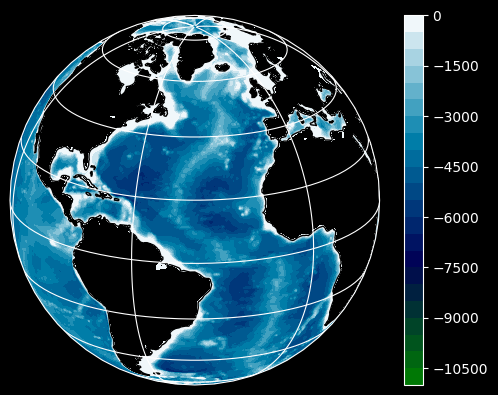

In [16]:
## Make a figure
plt.figure()

## Set the projection
ax = plt.axes(projection=ccrs.Orthographic(central_longitude=-40.0, central_latitude=20.0))
ax.set_global()

# Plot the topography below sea level
levels_sea = np.arange(-11000, 1, 500)
cs = ax.contourf(lon_grid, lat_grid, topo_grid, levels=levels_sea,
            cmap='ocean', transform=ccrs.PlateCarree())

# Add a colorbar for below sea level
plt.colorbar(cs)


## Add coastlines and gridlines
ax.coastlines()
ax.gridlines()


plt.show()

**1b Seafloor age**

Plot seafloor age looking at North Atlantic. First load the csv file provided, extract longitude, latitude, and age, reshape the data into a 2D array and then plot the seafloor age using the Orthographic projection.

(20 points)


In [17]:
## Load the seafloor age data
seafloor_age_data = pd.read_csv("data/age.csv")

In [18]:
seafloor_age_data

,longitude,latitude,age_Ma
0,-180.0,90.0,55.569
1,-179.8,90.0,55.568
2,-179.6,90.0,55.568
3,-179.4,90.0,55.569
4,-179.2,90.0,55.569
...,...,...,...
1622696,179.2,-90.0,NaN
1622697,179.4,-90.0,NaN
1622698,179.6,-90.0,NaN
1622699,179.8,-90.0,NaN


In [23]:
## extract longitude, latitude, and age
age_longitude = seafloor_age_data["longitude"]
age_latitude = seafloor_age_data["latitude"]
age = seafloor_age_data["age_Ma"]

## reshape the data to 2D arrays. Hint: the shape of the data is (901,1801)
age_grid = age.values.reshape(901, 1801)
age_long_grid = age_longitude.values.reshape(901, 1801)
age_lat_grid = age_latitude.values.reshape(901, 1801)

## check the shape of the data
print(f"Shape of age_grid: {age_grid.shape}, Shape of age_long_grid: {age_long_grid.shape}, Shape of age_lat_grid: {age_lat_grid.shape}")

## Downsample the data to make the plotting faster
age_long_grid = age_long_grid[::4, ::4]
age_lat_grid = age_lat_grid[::4, ::4]
age_grid = age_grid[::4, ::4]


Shape of age_grid: (901, 1801), Shape of age_long_grid: (901, 1801), Shape of age_lat_grid: (901, 1801)


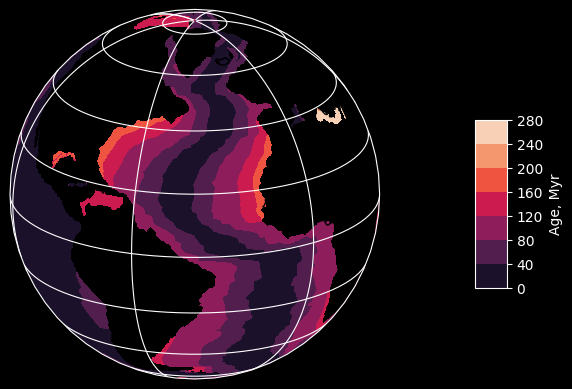

In [29]:
## Make a figure
plt.figure()

## Set the projection
ax = plt.axes(projection=ccrs.Orthographic(central_longitude=-40.0, central_latitude=20.0))
ax.set_global()

## Plot the seafloor age using the Orthographic projection
cs = ax.contourf(age_long_grid, age_lat_grid, age_grid,
            transform=ccrs.PlateCarree())

## Add coastlines and gridlines
ax.coastlines()
ax.gridlines()

## Add colorbar
color_ax = plt.axes([0.95, 0.3, 0.05, 0.35])
plt.colorbar(cs, cax=color_ax, label='Age, Myr')

plt.show()

Question: What patterns do you observe? Where is the youngest seafloor in relation to the seafloor ridges we observed in our map of topography? Where is the oldest seafloor? 

(5 points)

The youngest seafloor is on the furthest points from the continents.
The oldest seafloor is on the nearest points to the continents.

What was the position of the continents like when the oldest seafloor formed?

(5 points)

Africa, Eurasia, South America, North America were connected.

## 2. Earthquake Catalog

Based on the seafloor age data, we know that the tectonic plates are moving away from the ridges and towards the trenches.

The movement of the plates will compress and stretch the plates. The accumulated stress will eventually be too much and the plates will break, causing an earthquake.

Large earthquakes are often associated with plate boundaries. Let's continue to explore the earthquake data to see if we can find any patterns.


- 2022's tragic earthquake in Turkey

https://earthquake.usgs.gov/earthquakes/eventpage/us6000jllz/executive

https://earthquake.usgs.gov/earthquakes/map/?currentFeatureId=us6000jllz&extent=-26.11599,-43.59375&extent=61.39672,100.89844&sort=largest&listOnlyShown=true

<img src="figures/new-maps-of-global-geo.jpg" width=50%>
> Source: Hasterok et al., 2022


**2a Load the Earthquake Catalog**

Load the .csv (comma separated values) data file of all the earthquakes of magnitude 4 and higher from 2000 - 2012 in the ANSS (Advanced National Seismic System) Comprehensive Catalog or "ComCat." (data provided in the data folder).

The ANSS Comprehensive Catalog (ComCat) http://www.quake.geo.berkeley.edu/anss/catalog-search.html

This data set has the following columns:

```DateTime, Latitude, Longitude, Depth, Magnitude, MagType, NbStations, Gap, Distance, RMS, Source, EventID```

Let's import it using the pandas `pd.read_csv()` function. We can see the first 5 rows of the dataframe using the `.head()` function.

In [6]:
## Load the earthquake data. Hint: skipping the first 7 rows using header=7
EQ_data = pd.read_csv("data/ANSS_2000_2012.csv", header = 7)

## Check the first rows of the dataframe
EQ_data.head()


,DateTime,Latitude,Longitude,Depth,Magnitude,MagType,NbStations,Gap,Distance,RMS,Source,EventID
0,2000/01/01 01:19:26.99,41.927,20.543,10.0,4.8,ML,187,NaN,NaN,1.14,NEI,2.000010e+11
1,2000/01/01 02:12:13.45,-11.348,164.568,33.0,4.3,Mb,9,NaN,NaN,1.16,NEI,2.000010e+11
2,2000/01/01 04:30:10.37,-26.012,-68.803,105.0,4.5,Mb,44,NaN,NaN,0.91,NEI,2.000010e+11
3,2000/01/01 05:24:35.29,36.874,69.947,54.3,5.1,Mw,181,NaN,NaN,0.83,NEI,2.000010e+11
4,2000/01/01 05:58:19.78,-60.722,153.670,10.0,6.0,Mw,87,NaN,NaN,1.05,NEI,2.000010e+11


Recall from the first few weeks of class that Pandas dataframe columns can be accessed using bracket notation with the name of the column as a string:

In [24]:
## Access the Magnitude column
EQ_data['Magnitude']

0         4.8
1         4.3
2         4.5
3         5.1
4         6.0
         ... 
159016    4.0
159017    4.5
159018    4.4
159019    5.2
159020    4.6
Name: Magnitude, Length: 159021, dtype: float64

What is the largest magnitude earthquake in our catalog?

(5 points)

In [5]:
## Find the largest magnitude earthquake in our catalog
largest_magnitude = 

print(f"The largest magnitude earthquake in our catalog is {}")

When did the largest Earthquake happen?

(5 points)

In [6]:
## Find the date of the largest earthquake. Hint: using the `==` operator, e.g. EQ_data['DateTime'][EQ_data['Magnitude'] == largest_magnitude], to filter the dataframe, and `.values[0]` to get the first value of the filtered dataframe
largest_eq_date = 

print(f"The largest earthquake in our catalog happened on {}")

Where did the largest Earthquake happen (latitude and longitude)?

(5 points)

In [7]:
## Find the longitude and latitude of the largest earthquake. 
largest_eq_lon = 
largest_eq_lat = 

print(f"The largest earthquake in our catalog happened at {} longitude and {} latitude")

There are many colormaps available in Matplotlib: https://matplotlib.org/stable/tutorials/colors/colormaps.html

<img src="https://matplotlib.org/stable/_images/sphx_glr_colormaps_007_2_00x.png" width=30%>

There are many different markers available in Matplotlib

<img src="https://matplotlib.org/stable/_images/sphx_glr_marker_reference_002_2_00x.png" width=30%>

Let's plot a red square at the location of the largest earthquake in our catalog. 

To the `plt.scatter` function, add `s=100` to adjust the size of the marker, add `color='red'` to change the color, add `marker=s` to make it a square. 

(5 points)

In [8]:
## Make a figure
plt.figure()

## Set the projection using ccrs.Robinson(central_longitude=180)
ax = plt.axes(projection=ccrs.Robinson(central_longitude=180))
ax.set_global()

## Plot the largest earthquake, using s=100, marker='s', color='red'
plt.scatter()

## Add coastlines, stock image, and gridlines
ax.coastlines()
ax.stock_img()
ax.gridlines()

## Add a title
plt.title('2011 Tōhoku earthquake')    

plt.show()

Question: Watch the following video and comment on the effects of this earthquake:

https://www.youtube.com/watch?v=oWzdgBNfhQU

(5 points)

**2b Earthquake magnitude distribution**

How often do large earthquakes occur? To start addressing this question, let's plot a histogram of earthquake magnitudes.

(5 points)

In [10]:
## Make a figure
plt.figure()

## Plot a histogram of earthquake magnitudes, using bins=30, edgecolor='white'

## Label the axes and add a title

plt.show()

There are so many small earthquakes that we can't even see a bin for the Tohoku quake. 

Let's make the histogram on a log-scale. 

For any function, we can put a question mark before it to get its docstring. Let's do this for `plt.hist()`. 

Once you execute the cell below, you will see that there are a lot of options (which you can also view here: https://matplotlib.org/api/_as_gen/matplotlib.pyplot.hist.html). 

One of the options is to make the plot be on a log scale by setting `log=True`.

In [9]:
?plt.hist

Make a histogram of the Earthquake magnitude data on a log-scale

Set `log=True` within the `plt.hist` function.

Let's make sure that this figure has labeled axes using `plt.xlabel()` and `plt.ylabel()` and we can add a title as well using `plt.title()`

(5 points)

In [11]:
## Make a figure
plt.figure()

## Plot a histogram of earthquake magnitudes, using bins=30, edgecolor='white', log=True

## Label the axes and add a title

plt.show()

**2c Earthquake depth**

Let's see the range and frequency of depths where earthquakes occur. 

Make a histogram of earthquake depth. Do we want to set `log=True` in this case?

(5 points)

In [12]:
## Make a figure
plt.figure()

## Plot a histogram of earthquake depths, using bins=30, edgecolor='white'

## Label the axes and add a title

plt.show()

Questsion: At what depth are the majority of earthquakes? How deep do they extend? How does that compare to the typical depth of the lithosphere (~100 km)?

(5 points)

The map we made above is nice, but it doesn't tell us everything about our data. Let's create a map of the earthquake epicenters that colors the points by depth.

To do this, use the same `plt.scatter()` function, but add the option to set the color by depth. You can do this by having  `c=EQ_data['Depth']` within the function. 

You can customize the output by setting the minimum value for the color bar `vmin=0` and the maximum value `vmax=200`. 

You can also customize the colormap. A perceptually uniform sequential color map like `cmap='magma_r'` works well (https://matplotlib.org/tutorials/colors/colormaps.html). 

It is also nice to make the points partially see through by setting `alpha=0.5`. 

All of these customizations can be made by adding these arguments within the `plt.scatter()` function.

Make a map that colors points by depth by inserting these arguments in the `plt.scatter()` function in the code block below.

(15 points)

In [13]:
## Make a figure
fig = plt.figure(figsize=(15,15))

## Set the projection using ccrs.Robinson(central_longitude=180)
ax = plt.axes(projection=ccrs.Robinson(central_longitude=180))
ax.set_global()

## Plot the epicenters of the earthquakes, using c=EQ_data['Depth'], s=10, vmin=0,vmax=200,cmap='magma_r',alpha=0.5
plt.scatter()

## Add coastlines, stock image, and gridlines
ax.coastlines()
ax.stock_img()
ax.gridlines()

## Add a colorbar
plt.colorbar(shrink=0.4, label='depth (km)')

## Add a title
plt.title('Earthquake Epicenters 2000-2012')

plt.show()

Question: What depth of earthquakes occur at mid-ocean ridges?

(5 points)

Question: What depth of earthquakes occur at subduction zones?

(5 points)

<img src="figures/slab_eq.png" width=50%>

> Source: Fundamentals of Geophysics (2nd Edition) Lowrie, W.

<img src="figures/slab_eq2.png" width=50%>

> A cross-section through a subduction zone. Red points are earthquake focus points. The most active region is the zone of contact between the plates. There is a back-arc seismic zone in the overriding plate. Below ~70 km depth earthquakes occur within the subducting plate, this region is call the Wadati-Benioff seismic zone.

The earthquakes at trenches (like around the Pacific ocean's 'ring of fire') get deeper in a systematic way. The deepest earthquakes are the farthest from the trench. This reveals the location of the downgoing slabs.

**2d - The Andean & Japanese subduction zones**

Let's look at a subset of this earthquake catalog across the Andes in South America. The code below is filtering the data frame to only include those between 20ºS and 25ºS latitude and 75ºW and 60ºW longitude.

In [17]:
## Filter the data frame to only include those between 20ºS and 25ºS latitude and 75ºW and 60ºW longitude
min_lat = -25
max_lat = -20
min_lon = -75
max_lon = -60 
selected_quakes = EQ_data.loc[(EQ_data['Latitude'] > min_lat) & (EQ_data['Latitude'] < max_lat) & 
                    (EQ_data['Longitude'] > min_lon) & (EQ_data['Longitude'] < max_lon)]

Let's make a map of the epicenters of these earthquakes following the same procedure as we did above.

(10 points)

In [14]:
## Make a figure
plt.figure()

## Set the projection using ccrs.Robinson(central_longitude=180)
ax = plt.axes(projection=ccrs.Robinson(central_longitude=180))
ax.set_global()

## Plot the epicenters of the earthquakes, using s=10, marker='.', color='red'
plt.scatter()

## Add coastlines, stock image, and gridlines
ax.coastlines()
ax.stock_img()
ax.gridlines()

## Add a title
plt.title()    

plt.show()

Let's take all of the earthquakes within that region and plot earthquake depth on the y-axis and earthquake location on the x-axis. 

Labeling axes is super important in science! Don't make plots without labeled axes!

(15 points)

In [15]:
## Make a figure
plt.figure()

## Plot the epicenters of the earthquakes, using longitude on the x-axis and depth on the y-axis, using s=10, marker='.'. 
## Hint: Using -selected_quakes['Depth'] to plot deeper earthquakes lower on the y-axis

## Label the axes and add a title

plt.show()

Now let's look at the subduction zone off the east coast of Japan. 

Please find the correct latitude and longitude range for this region and plot the earthquakes on a map and make a similar depth vs. longitude plot (or depth vs latitude plot) for the Japanese arc.

(25 points)

In [16]:
# Define the latitude and longitude range

# subselect earthquakes within that range.

Question: What direction is subduction occuring below South America and Japan? Are they towards the east or west?

(5 points)


**2e Relationship between earthquake location and plate boundaries**

In stead of using the prepared earthquake catalog, let's use the USGS API to import a global earthquake catalog (Magnitude >= 6.0).

This can be very useful if you want to get the latest earthquake data.

Update the start_day and end_day (from 2010-01-01 to 2025-01-01) to get a query url that will return earthquakes that occured over the past 10 years.

(5 points)

In [17]:
## Define the start and end day from 2010-01-01 to 2025-01-01 and the minimum magnitude = 6.0
start_day = 
end_day = 
min_magnitude = 

## Define the standard url
standard_url = 'https://earthquake.usgs.gov/fdsnws/event/1/query?format=csv&orderby=magnitude'

## Define the query url
query_url = f"{}&starttime={}&endtime={}&minmagnitude={}"

## Read the data from the query url into a dataframe
earthquake_data = pd.read_csv()

## Print the first rows of the dataframe
earthquake_data.head()

We can now plot the plate boundaries (using a ShapeFile layer in the data folder) and earthquake locations together

I took the plate boundaries provided by the US Geological Survey (USGS) and split them by their categorization into trenches (subduction zones), ridges (spreading centers) and transform (strike-slip boundaries like the San Andreas fault).

The code below makes a map where these different plate boundaries are represented by different color lines. Please add the earthquake locations to this map as well.

(5 points)

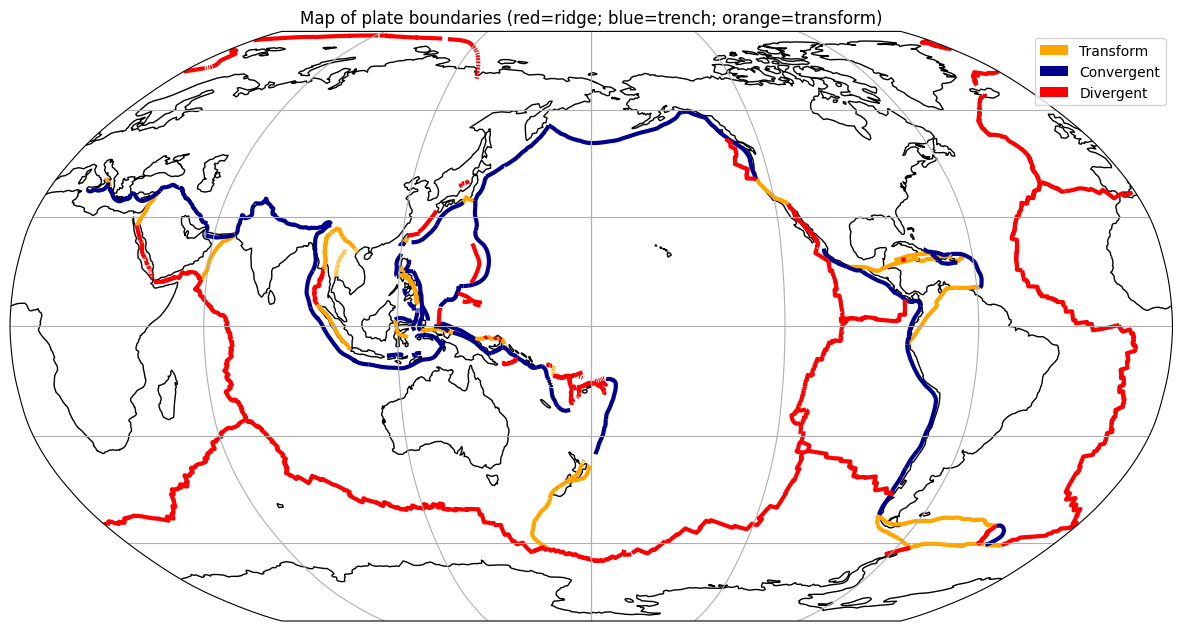

In [21]:
## Make a figure
plt.figure(figsize=(15,15))

## Set the projection using ccrs.Robinson(central_longitude=180)
ax = plt.axes(projection=ccrs.Robinson(central_longitude=180))
ax.set_global()

## Add coastlines, stock image, and gridlines
ax.coastlines()
ax.gridlines()

## Read the data from the shapefile
data = Reader('./data/Plate_Boundaries_transform.shp')

## Add the transform plate boundaries to the map
ax.add_geometries(data.geometries(), crs=ccrs.PlateCarree(), 
                  edgecolor='orange', facecolor='none',
                  linewidth=3)

## Read the data from the shapefile
data = Reader('./data/Plate_Boundaries_trenches.shp')

## Add the trench plate boundaries to the map
ax.add_geometries(data.geometries(), crs=ccrs.PlateCarree(), 
                  edgecolor='darkblue', facecolor='none',
                  linewidth=3)

## Read the data from the shapefile
data = Reader('./data/Plate_Boundaries_ridges.shp')

## Add the ridge plate boundaries to the map
ax.add_geometries(data.geometries(), crs=ccrs.PlateCarree(), 
                  edgecolor='red', facecolor='none',
                  linewidth=3)

## Make patches to add to a legend
trans = mpatches.Rectangle((0, 0), 1, 1, facecolor="orange")
con = mpatches.Rectangle((0, 0), 1, 1, facecolor="darkblue")
div = mpatches.Rectangle((0, 0), 1, 1, facecolor="red")
labels = ['Transform','Convergent','Divergent']
plt.legend([trans, con, div], labels)

## Add a title
plt.title('Map of plate boundaries (red=ridge; blue=trench; orange=transform)')

## Plot the earthquake locations on the map. Adjust the color and size of the points as need to make it look nice.
# plt.scatter()

# plt.colorbar(shrink=0.4, label='depth (km)')

plt.show()

Question: Where do the majority of earthquakes occur?

(5 points)

Question: What do those locations correspond with? Trenches, ridges, or transform boundaries?

(5 points)
